# Fase 1: Reconhecimento de pessoas numa imagem 

# Implementar um CNN para essa finalidade, experimentando os conceitos de blocos, otimizadores, funções de custo, transferência de aprendizado e regularização de redes

# Qual CNN? Implementar uma própria e usar arquiteturas clássicas
# Objetivo? Dado uma imagem, dizer se ali tem pessoas (não precisa dizer onde)
# O que entregar? Jupyter Notebook, todo documentado, com exemplos e explicações
# Data de Entrega: 08/05/2026
# Análise crítica: início: 11/05/2026 - fim: 13/05/2026



# Datasets:
# [Básico] http://host.robots.ox.ac.uk/pascal/VOC
# [Básico] https://www.cs.toronto.edu/~kriz/cifar.html
# [Misturado] https://cocodataset.org/#home
# [Misturado] https://data.vision.ee.ethz.ch/cvl/rrothe/imdb-wiki/
# [Reconhecimento facial] https://www.aiaaic.org/aiaaic-repository/ai-algorithmic-and-automation-incidents/labeled-faces-in-the-wild-lfw-dataset
# [Reconhecimento facial] https://www.kaggle.com/datasets/hearfool/vggface2
# [Expressão facial] https://www.nist.gov/programs-projects/face-recognition-technology-feret
# [Grande] https://storage.googleapis.com/openimages/web/index.html


In [ ]:
# TODO:
# Ensaios iniciais
# Checar se dá pra aproveitar alguma coisa desse notebook para o trabalho realizar correções após analise crítica geral com o grupo antes da entrega dia 08-04-2026
# Confirmar se o número de épocas está suficiente e se tem relação direta com as saídas da função de perda
# Confirmar se o tempo de executação pode ser justificado pelo treinamento e ajustamento de aproximadamente 160.000 neurônios da rede MobileNetV2
# Pytorch ou TensorFlow?
# Utilizar os datasets do roreiro do trabalho

# 1 - Imports + caminhos

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# dataset de imagens com rostos
# Utilizado o dataset CelebA como classe positiva (pessoas) 
image_dir = "/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"
# arquivos de atributos 
attr_path = "/datasets/jessicali9530/celeba-dataset/list_attr_celeba.csv"
# para imagens sem pessoas (usado como classe negativa)
# CIFAR-10 como classe negativa, permitindo treinar o modelo para distinguir entre imagens com e sem pessoas."
(x_train_cifar, _), _ = tf.keras.datasets.cifar10.load_data()

ModuleNotFoundError: No module named 'tensorflow'

# 2 - Carregar labels

In [ ]:
df = pd.read_csv(attr_path)

# reduzção do dataset
df = df.sample(1000, random_state=42)
df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
93241,093242.jpg,-1,-1,-1,-1,-1,-1,-1,-1,1,...,1,-1,-1,1,-1,-1,-1,-1,-1,1
121413,121414.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
10624,010625.jpg,1,-1,-1,1,-1,-1,-1,1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
82523,082524.jpg,-1,1,1,1,-1,-1,1,-1,-1,...,-1,1,-1,-1,-1,-1,1,-1,-1,1
73192,073193.jpg,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,-1,-1,-1,-1


# 3 - Carregar imagens (CelebaA e Cifar)

In [ ]:
images = []
labels = []

# PESSOAS (CelebA)
for _, row in df.iterrows():
    img_path = os.path.join(image_dir, row['image_id'])

    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img) / 255.0

    images.append(img)
    labels.append(1)

# (CIFAR) Dataset com objetos diversos (carros, animais, etc.), usado como classe negativa
x_cifar = x_train_cifar[:1000]
x_cifar = tf.image.resize(x_cifar, (224, 224)) / 255.0

for img in x_cifar:
    images.append(img.numpy())
    labels.append(0)

X = np.array(images)
y = np.array(labels)

print("Shape:", X.shape, y.shape)

Shape: (2000, 224, 224, 3) (2000,)


# 4 - Construção da CNN

In [ ]:
model_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    # saída só aponta a problabilidade de ter pessoa ou não
    layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 5 - Treinamento da CNN construída

In [ ]:
history_cnn = model_cnn.fit(
    X, y,
    epochs=3,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.7155 - loss: 0.7561 - val_accuracy: 1.0000 - val_loss: 0.2097
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9825 - loss: 0.0698 - val_accuracy: 0.9975 - val_loss: 0.0508
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9950 - loss: 0.0278 - val_accuracy: 0.9900 - val_loss: 0.0337


# 6 - Gráfico CNN construída

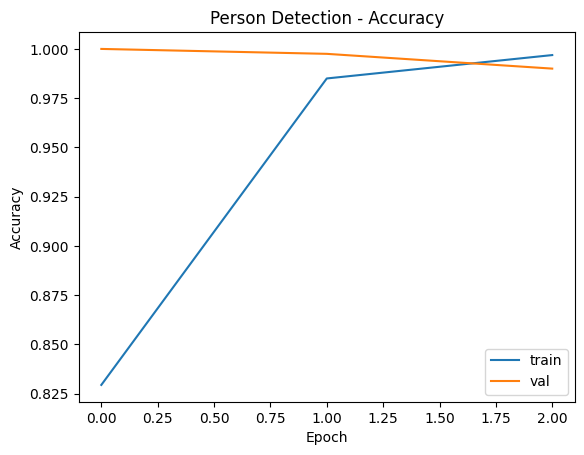

In [ ]:
plt.plot(history_cnn.history['accuracy'], label='train')
plt.plot(history_cnn.history['val_accuracy'], label='val')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Person Detection - Accuracy")
plt.legend()

plt.show()

# 7 - Transfer Learning
# Treinamento e congelamento de parametros

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 8 - Treinamento inicial

In [ ]:
# XXX: model_path e model.save
# optando por salvar o modelo, caso o mesmo nao exista, 
# para pular a etapa de treinamento toda vez que perder a sessão
model_path = "/modelos/meu-modelo-trabalho-svc.h5"
if os.path.exists(model_path):
    print("Carregando modelo...")
    model = load_model(model_path)
else:
    print("Treinando modelo...")
    
    history = model.fit(
        X, y,
        epochs=5,
        validation_split=0.2,
        batch_size=32
    )
    
    model.save("/modelos/meu-modelo-trabalho-svc.h5")


Treinando modelo...
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - accuracy: 0.9443 - loss: 0.1190 - val_accuracy: 1.0000 - val_loss: 7.3094e-04
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 1.0000 - loss: 9.4855e-05 - val_accuracy: 1.0000 - val_loss: 9.2100e-05
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 1.0000 - loss: 1.0762e-04 - val_accuracy: 1.0000 - val_loss: 9.5598e-05
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 1.0000 - loss: 5.8819e-05 - val_accuracy: 1.0000 - val_loss: 9.1652e-05
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 1.0000 - loss: 4.0966e-05 - val_accuracy: 1.0000 - val_loss: 8.4197e-05


# 8 - Fine-tuning

In [ ]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    X, y,
    epochs=3,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 279ms/step - accuracy: 0.9829 - loss: 0.0546 - val_accuracy: 1.0000 - val_loss: 1.6628e-06
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.9981 - loss: 0.0105 - val_accuracy: 1.0000 - val_loss: 8.2227e-07
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.9977 - loss: 0.0088 - val_accuracy: 1.0000 - val_loss: 4.6597e-07


# 9 - Gráfico

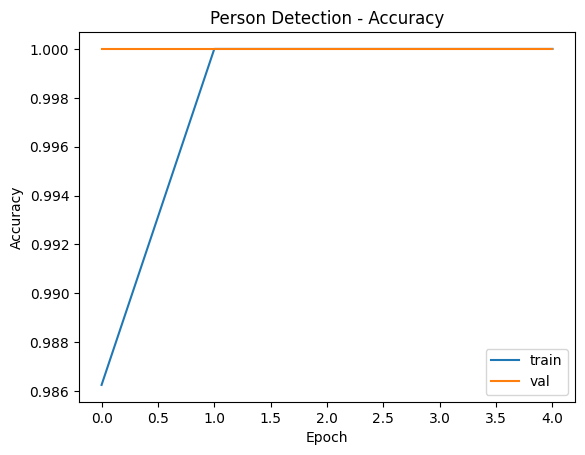

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Person Detection - Accuracy")
plt.legend()

plt.show()

#  Testando com imagens do dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[[0.99999785]]
Tem pessoa


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

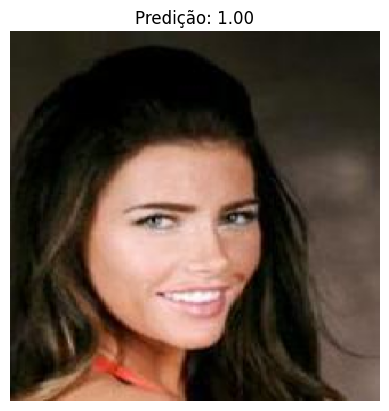

In [ ]:
# img_path = image_dir + "/000021.jpg"
# img_path = image_dir + "/000022.jpg"
# img_path = image_dir + "/000023.jpg"
# img_path = image_dir + "/000024.jpg"
# img_path = image_dir + "/000025.jpg"
# img_path = image_dir + "/000026.jpg"
img_path = image_dir + "/000027.jpg"

img = load_img(img_path, target_size=(224, 224))
img = img_to_array(img) / 255.0

img = np.expand_dims(img, axis=0)

pred = model.predict(img)

print(pred)
# Interpretacao
if pred > 0.5:
    print("Tem pessoa")
else:
    print("Não tem pessoa")
# Teste visual
import matplotlib.pyplot as plt

plt.imshow(img[0])
plt.title(f"Predição: {pred[0][0]:.2f}")
plt.axis('off')

# Observações Finais:

In [ ]:
# A construção de uma CNN própria revelou dificuldade de generalização para imagens fora dos datasets celeba e cifar, ou seja, fotos sem rostos explícitos, 
# indicando que o modelo aprendeu padrões específicos do dataset - que são os rostos,
# enquanto o transfer learning apresentou melhor capacidade de generalização.
